# 02 · Control de Calidad Genómica

**Objetivo:** Evaluar la calidad de los ensamblajes FASTA descargados en el notebook 01 y
eliminar genomas que no cumplan los criterios mínimos de calidad antes de pasar a la extracción de k-mers.

| Métrica | Umbral | Justificación |
|---|---|---|
| N50 | > 20 kb | Ensamblajes muy fragmentados introducen ruido en los k-mers |
| Nº contigs | < 500 | Fragmentación excesiva indica mala calidad de secuenciación |
| GC% | 50 – 64% | Rango esperado para *K. pneumoniae* (~57.5% de media) |
| Tamaño | 4.5 – 6.5 Mb | Rango típico del genoma de *K. pneumoniae* |

**Input:** `datos/procesados/ids_completos.json` + `datos/brutos/genomas_fasta/`  
**Output:** `datos/procesados/informe_qc_genomas.csv` + `datos/procesados/ids_qc_ok.json`

> **Nota metodológica:** El QC se aplica **antes** de cualquier split train/test.
> Aplicarlo después introduciría data leakage si los criterios de exclusión correlacionan con el fenotipo.

---
## Celda 0 — Imports y configuración global

In [1]:
# ─── Librería estándar ────────────────────────────────────────────────────────
import json
import logging
from pathlib import Path
from datetime import datetime

# ─── Third-party ──────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from tqdm.notebook import tqdm

# ─── Logging ──────────────────────────────────────────────────────────────────
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
    datefmt="%H:%M:%S",
)
log = logging.getLogger(__name__)

# ─── Rutas del proyecto ───────────────────────────────────────────────────────
ROOT       = Path.cwd().parent
DIR_BRUTOS = ROOT / "datos" / "brutos"
DIR_FASTA  = DIR_BRUTOS / "genomas_fasta"
DIR_PROC   = ROOT / "datos" / "procesados"
DIR_FIGS   = ROOT / "informes" / "figuras"

for d in [DIR_PROC, DIR_FIGS]:
    d.mkdir(parents=True, exist_ok=True)

# ─── Umbrales QC ─────────────────────────────────────────────────────────────
# Basados en: PATRIC assembly QC guidelines + literatura AMR-ML (Moradigaravand 2018)
QC_MIN_N50_BP   = 20_000   # N50 mínimo — 20 kb
QC_MAX_CONTIGS  = 500      # Máximo número de contigs
QC_MIN_GC       = 50.0     # GC% mínimo para K. pneumoniae
QC_MAX_GC       = 64.0     # GC% máximo para K. pneumoniae
QC_MIN_SIZE_MB  = 4.5      # Tamaño mínimo (Mb)
QC_MAX_SIZE_MB  = 6.5      # Tamaño máximo (Mb)  — genoma típico ~5.5 Mb

print(f"Proyecto raíz : {ROOT}")
print(f"FASTA dir     : {DIR_FASTA}")
print(f"Timestamp     : {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print()
print("── Umbrales QC ──────────────────────────────────────")
print(f"  N50        : ≥ {QC_MIN_N50_BP:,} bp  ({QC_MIN_N50_BP/1000:.0f} kb)")
print(f"  Contigs    : <  {QC_MAX_CONTIGS}")
print(f"  GC%%        : {QC_MIN_GC} – {QC_MAX_GC} %%")
print(f"  Tamaño     : {QC_MIN_SIZE_MB} – {QC_MAX_SIZE_MB} Mb")

Proyecto raíz : /mnt/c/Users/Alumno1/ablda/amr-resistance-prediction
FASTA dir     : /mnt/c/Users/Alumno1/ablda/amr-resistance-prediction/datos/brutos/genomas_fasta
Timestamp     : 2026-03-18 13:18:11

── Umbrales QC ──────────────────────────────────────
  N50        : ≥ 20,000 bp  (20 kb)
  Contigs    : <  500
  GC%%        : 50.0 – 64.0 %%
  Tamaño     : 4.5 – 6.5 Mb


---
## Celda 1 — Carga de IDs y fenotipos (output del notebook 01)

In [2]:
# ── IDs con FASTA descargado y fenotipo confirmado ────────────────────────────
ruta_ids = DIR_PROC / "ids_completos.json"
assert ruta_ids.exists(), f"No se encuentra {ruta_ids} — ejecuta el notebook 01 primero"

with open(ruta_ids) as f:
    ids_objetivo = json.load(f)

log.info(f"IDs objetivo cargados: {len(ids_objetivo)}")

# ── Fenotipos (para el análisis de balance post-QC) ───────────────────────────
df_fenotipos_raw = pd.read_csv(DIR_BRUTOS / "amr_fenotipos.csv")

df_fenotipos = (
    df_fenotipos_raw[
        df_fenotipos_raw["resistant_phenotype"].isin(["Susceptible", "Resistant"])
    ]
    .drop_duplicates(subset="genome_id", keep="first")
    [["genome_id", "resistant_phenotype"]]
    .assign(genome_id=lambda df: df["genome_id"].astype(str))
    .reset_index(drop=True)
)

log.info(f"Fenotipos disponibles: {len(df_fenotipos)}")
print()
print("Distribución de fenotipos (input):")
print(df_fenotipos["resistant_phenotype"].value_counts())

13:18:15 [INFO] IDs objetivo cargados: 600
13:18:15 [INFO] Fenotipos disponibles: 7552



Distribución de fenotipos (input):
resistant_phenotype
Resistant      4702
Susceptible    2850
Name: count, dtype: int64


---
## Celda 2 — Funciones de análisis de ensamblaje

**Implementación propia** (sin dependencias externas como `quast`) para mantener el entorno ligero
y tener control total sobre las métricas calculadas.

**N50** — longitud del contig más corto del conjunto mínimo de contigs que cubre el 50% del ensamblaje.
Mide continuidad: cuanto más alto, mejor.

In [3]:
def parse_fasta(path: Path) -> list[tuple[str, str]]:
    """
    Lee un FASTA y devuelve lista de (header, sequence).
    Lee línea a línea para no cargar genomas enteros en RAM.
    """
    contigs = []
    header = None
    seq_parts: list[str] = []

    with open(path) as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            if line.startswith(">"):
                if header is not None:
                    contigs.append((header, "".join(seq_parts)))
                    seq_parts = []
                header = line[1:]
            else:
                seq_parts.append(line.upper())

    if header is not None:
        contigs.append((header, "".join(seq_parts)))

    return contigs


def calcular_nx(
    lengths_sorted: np.ndarray,
    total_length: int,
    x: float = 0.5,
) -> tuple[int, int]:
    """
    Calcula Nx (e.g. N50) y Lx para un ensamblaje.

    Parameters
    ----------
    lengths_sorted : longitudes de contigs ordenadas mayor→menor
    total_length   : longitud total del ensamblaje
    x              : fracción objetivo (0.5 → N50, 0.9 → N90)

    Returns
    -------
    (Nx_bp, Lx_count)
    """
    objetivo   = total_length * x
    acumulado  = 0
    for i, length in enumerate(lengths_sorted, 1):
        acumulado += length
        if acumulado >= objetivo:
            return int(length), i
    return int(lengths_sorted[-1]), len(lengths_sorted)


def compute_assembly_stats(fasta_path: Path) -> dict:
    """
    Calcula el panel completo de métricas de calidad para un ensamblaje FASTA.

    Métricas:
        n_contigs        : número total de contigs/scaffolds
        total_length_bp  : longitud total (bp)
        total_length_mb  : longitud total (Mb)
        gc_percent       : %GC sobre bases no-N
        n50 / l50        : N50 (bp) y L50 (nº contigs)
        n90 / l90        : N90 (bp) y L90 (nº contigs)
        largest_contig   : contig más largo (bp)
        mean_length      : longitud media de contigs (bp)
        n_contigs_1kb    : contigs con longitud ≥ 1 kb
    """
    genome_id = fasta_path.stem

    try:
        contigs = parse_fasta(fasta_path)
    except Exception as e:
        return {"genome_id": genome_id, "error": f"Error lectura: {e}"}

    if not contigs:
        return {"genome_id": genome_id, "error": "FASTA vacío o sin contigs"}

    sequences    = [seq for _, seq in contigs]
    lengths      = np.array([len(s) for s in sequences], dtype=np.int64)
    lengths_desc = np.sort(lengths)[::-1]
    total_length = int(lengths.sum())

    # GC% — excluir bases N/n
    all_seq = "".join(sequences)
    n_gc    = all_seq.count("G") + all_seq.count("C")
    n_base  = len(all_seq) - all_seq.count("N")
    gc_pct  = round(n_gc / n_base * 100, 3) if n_base > 0 else 0.0

    n50, l50 = calcular_nx(lengths_desc, total_length, 0.50)
    n90, l90 = calcular_nx(lengths_desc, total_length, 0.90)

    return {
        "genome_id"       : genome_id,
        "n_contigs"       : int(len(lengths)),
        "total_length_bp" : total_length,
        "total_length_mb" : round(total_length / 1e6, 3),
        "gc_percent"      : gc_pct,
        "n50"             : n50,
        "l50"             : l50,
        "n90"             : n90,
        "l90"             : l90,
        "largest_contig"  : int(lengths_desc[0]),
        "mean_length"     : round(float(lengths.mean()), 1),
        "n_contigs_1kb"   : int((lengths >= 1_000).sum()),
        "error"           : None,
    }

---
## Celda 3 — Ejecución del QC sobre todos los genomas

> ⏱️ Con 600 genomas de ~5 MB cada uno: **~5–15 minutos** dependiendo del disco.

In [4]:
log.info(f"Iniciando QC para {len(ids_objetivo)} genomas...")

stats_list = []
for genome_id in tqdm(ids_objetivo, desc="QC ensamblajes"):
    fasta_path = DIR_FASTA / f"{genome_id}.fasta"
    if not fasta_path.exists():
        stats_list.append({"genome_id": genome_id, "error": "FASTA no encontrado"})
        continue
    stats_list.append(compute_assembly_stats(fasta_path))

df_qc_all = pd.DataFrame(stats_list)

# Separar genomas con error de lectura de los parseados correctamente
df_errores = df_qc_all[df_qc_all["error"].notna()].copy()
df_qc      = df_qc_all[df_qc_all["error"].isna()].copy()

log.info(
    f"Procesados: {len(df_qc_all)} | "
    f"Con métricas: {len(df_qc)} | "
    f"Errores de lectura: {len(df_errores)}"
)

if not df_errores.empty:
    log.warning("Genomas con error de lectura:")
    print(df_errores[["genome_id", "error"]])

print()
print("Estadísticas descriptivas de métricas de ensamblaje:")
df_qc[["n_contigs", "total_length_mb", "gc_percent",
       "n50", "l50", "largest_contig"]].describe().round(2)

13:18:34 [INFO] Iniciando QC para 600 genomas...


QC ensamblajes:   0%|          | 0/600 [00:00<?, ?it/s]

13:19:59 [INFO] Procesados: 600 | Con métricas: 600 | Errores de lectura: 0



Estadísticas descriptivas de métricas de ensamblaje:


,n_contigs,total_length_mb,gc_percent,n50,l50,largest_contig
count,600.00,600.00,600.00,600.00,600.00,600.00
mean,178.49,5.54,57.15,565487.12,16.25,903355.08
std,298.54,0.31,0.79,1275522.98,44.56,1231779.74
min,1.00,0.03,39.21,345.00,1.00,2707.00
25%,72.00,5.44,57.07,147457.75,6.00,369944.75
50%,104.00,5.55,57.21,206831.00,9.00,514884.50
75%,160.25,5.66,57.33,320712.75,12.00,804144.00
max,2832.00,6.98,59.68,5587050.00,547.00,5587050.00


---
## Celda 4 — Visualización de métricas y umbrales

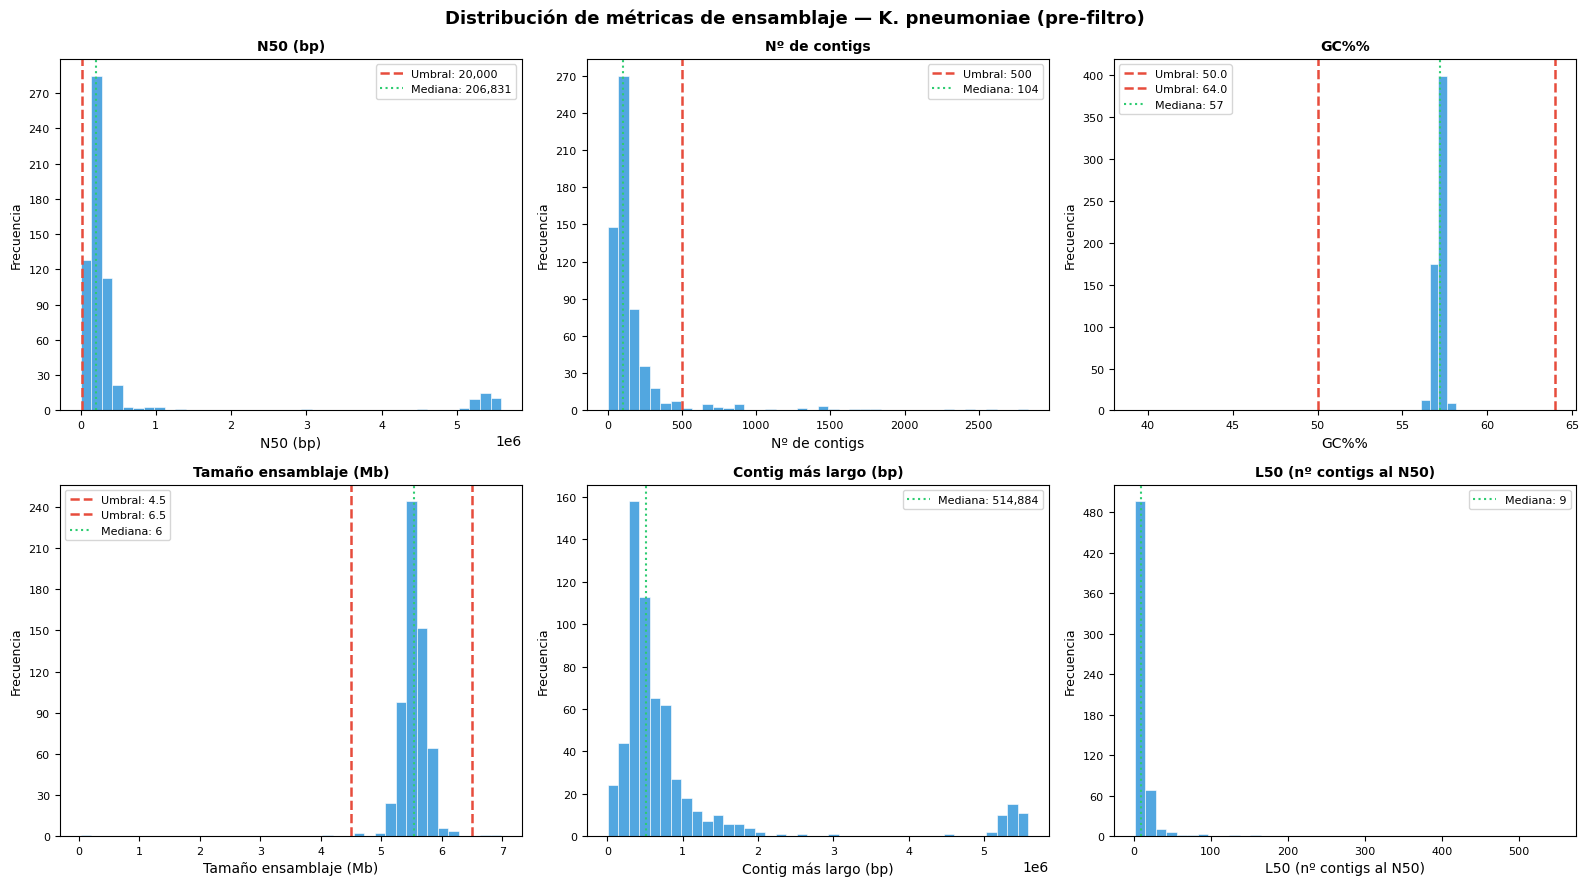

13:20:26 [INFO] Figura guardada → /mnt/c/Users/Alumno1/ablda/amr-resistance-prediction/informes/figuras/02_qc_distribuciones.png


In [5]:
COLOR_PASS = "#3498db"
COLOR_UMBR = "#e74c3c"

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle(
    "Distribución de métricas de ensamblaje — K. pneumoniae (pre-filtro)",
    fontsize=13, fontweight="bold",
)

# (columna, label_eje, umbral_min, umbral_max)
metricas = [
    ("n50",             "N50 (bp)",                QC_MIN_N50_BP,  None),
    ("n_contigs",       "Nº de contigs",            None,           QC_MAX_CONTIGS),
    ("gc_percent",      "GC%%",                      QC_MIN_GC,      QC_MAX_GC),
    ("total_length_mb", "Tamaño ensamblaje (Mb)",   QC_MIN_SIZE_MB, QC_MAX_SIZE_MB),
    ("largest_contig",  "Contig más largo (bp)",    None,           None),
    ("l50",             "L50 (nº contigs al N50)",  None,           None),
]

for ax, (col, label, vmin, vmax) in zip(axes.flat, metricas):
    data = df_qc[col].dropna()
    ax.hist(data, bins=40, color=COLOR_PASS, edgecolor="white", alpha=0.85, linewidth=0.5)

    for val, ls, anchor in [(vmin, "--", "right"), (vmax, "--", "left")]:
        if val is not None:
            ax.axvline(val, color=COLOR_UMBR, linestyle=ls, linewidth=1.8,
                       label=f"Umbral: {val:,}")

    # Anotación con mediana
    med = data.median()
    ax.axvline(med, color="#2ecc71", linestyle=":", linewidth=1.5,
               label=f"Mediana: {med:,.0f}")

    ax.set_xlabel(label, fontsize=10)
    ax.set_ylabel("Frecuencia", fontsize=9)
    ax.set_title(label, fontsize=10, fontweight="bold")
    ax.legend(fontsize=8)
    ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax.tick_params(labelsize=8)

plt.tight_layout()
ruta_fig = DIR_FIGS / "02_qc_distribuciones.png"
plt.savefig(ruta_fig, dpi=150, bbox_inches="tight")
plt.show()
log.info(f"Figura guardada → {ruta_fig}")

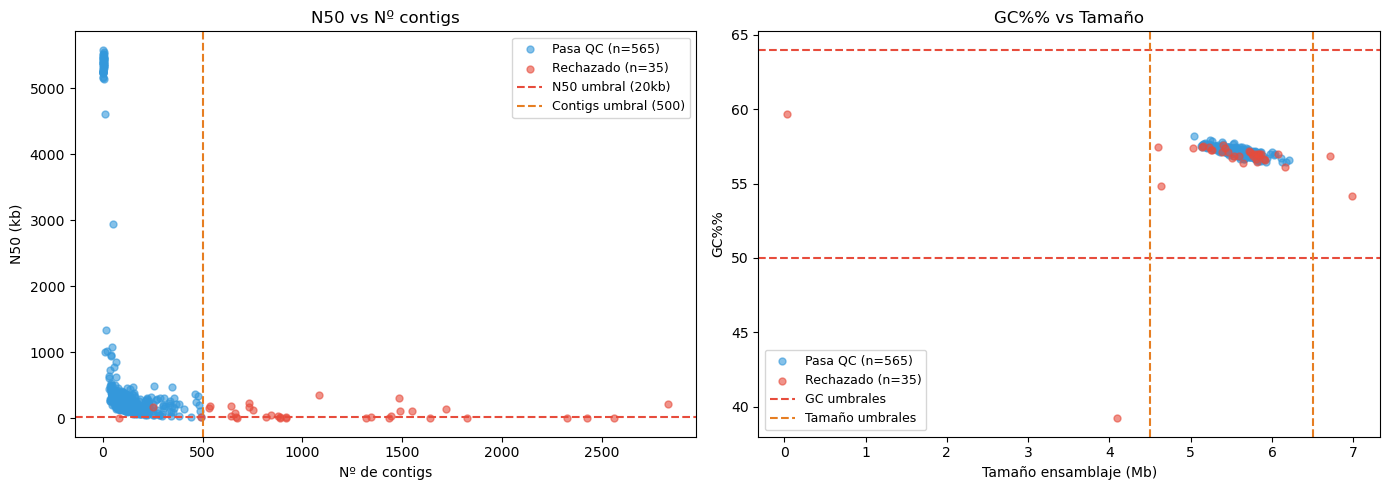

13:20:46 [INFO] Figura guardada → /mnt/c/Users/Alumno1/ablda/amr-resistance-prediction/informes/figuras/02_qc_scatter.png


In [6]:
# ── Scatter N50 vs n_contigs  (los dos criterios más discriminativos) ─────────
# Coloreado por aprobado/rechazado para ver cuántos caen fuera

pasa_provisional = (
    (df_qc["n50"]            >= QC_MIN_N50_BP) &
    (df_qc["n_contigs"]      <  QC_MAX_CONTIGS) &
    (df_qc["gc_percent"].between(QC_MIN_GC, QC_MAX_GC)) &
    (df_qc["total_length_mb"].between(QC_MIN_SIZE_MB, QC_MAX_SIZE_MB))
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: N50 vs n_contigs
ax = axes[0]
for pasa, color, label in [(True, COLOR_PASS, "Pasa QC"), (False, COLOR_UMBR, "Rechazado")]:
    mask = pasa_provisional == pasa
    ax.scatter(
        df_qc.loc[mask, "n_contigs"],
        df_qc.loc[mask, "n50"] / 1000,
        c=color, alpha=0.6, s=25, label=f"{label} (n={mask.sum()})"
    )
ax.axhline(QC_MIN_N50_BP / 1000, color=COLOR_UMBR, linestyle="--", linewidth=1.5, label=f"N50 umbral ({QC_MIN_N50_BP//1000}kb)")
ax.axvline(QC_MAX_CONTIGS,       color="#e67e22",  linestyle="--", linewidth=1.5, label=f"Contigs umbral ({QC_MAX_CONTIGS})")
ax.set_xlabel("Nº de contigs")
ax.set_ylabel("N50 (kb)")
ax.set_title("N50 vs Nº contigs")
ax.legend(fontsize=9)

# Plot 2: GC% vs tamaño
ax = axes[1]
for pasa, color, label in [(True, COLOR_PASS, "Pasa QC"), (False, COLOR_UMBR, "Rechazado")]:
    mask = pasa_provisional == pasa
    ax.scatter(
        df_qc.loc[mask, "total_length_mb"],
        df_qc.loc[mask, "gc_percent"],
        c=color, alpha=0.6, s=25, label=f"{label} (n={mask.sum()})"
    )
ax.axhline(QC_MIN_GC,       color=COLOR_UMBR, linestyle="--", linewidth=1.5)
ax.axhline(QC_MAX_GC,       color=COLOR_UMBR, linestyle="--", linewidth=1.5, label=f"GC umbrales")
ax.axvline(QC_MIN_SIZE_MB,  color="#e67e22",  linestyle="--", linewidth=1.5)
ax.axvline(QC_MAX_SIZE_MB,  color="#e67e22",  linestyle="--", linewidth=1.5, label=f"Tamaño umbrales")
ax.set_xlabel("Tamaño ensamblaje (Mb)")
ax.set_ylabel("GC%%")
ax.set_title("GC%% vs Tamaño")
ax.legend(fontsize=9)

plt.tight_layout()
ruta_fig2 = DIR_FIGS / "02_qc_scatter.png"
plt.savefig(ruta_fig2, dpi=150, bbox_inches="tight")
plt.show()
log.info(f"Figura guardada → {ruta_fig2}")

---
## Celda 5 — Aplicación de filtros QC

In [7]:
def aplicar_filtros_qc(df: pd.DataFrame) -> pd.DataFrame:
    """
    Añade columnas booleanas por criterio y 'pasa_qc' global.
    No modifica el DataFrame original.
    """
    df = df.copy()
    df["ok_n50"]     = df["n50"]             >= QC_MIN_N50_BP
    df["ok_contigs"] = df["n_contigs"]       <  QC_MAX_CONTIGS
    df["ok_gc"]      = df["gc_percent"].between(QC_MIN_GC, QC_MAX_GC)
    df["ok_size"]    = df["total_length_mb"].between(QC_MIN_SIZE_MB, QC_MAX_SIZE_MB)
    df["pasa_qc"]    = df[["ok_n50", "ok_contigs", "ok_gc", "ok_size"]].all(axis=1)
    return df


df_qc = aplicar_filtros_qc(df_qc)

# ── Resumen por criterio ─────────────────────────────────────────────────────
criterios = {
    "ok_n50"    : f"N50 < {QC_MIN_N50_BP:,} bp",
    "ok_contigs": f"Contigs ≥ {QC_MAX_CONTIGS}",
    "ok_gc"     : f"GC fuera de [{QC_MIN_GC}%%, {QC_MAX_GC}%%]",
    "ok_size"   : f"Tamaño fuera de [{QC_MIN_SIZE_MB}, {QC_MAX_SIZE_MB}] Mb",
}

print("=" * 58)
print("RESUMEN DE FILTROS QC")
print("=" * 58)
for col, desc in criterios.items():
    n_falla = int((~df_qc[col]).sum())
    pct     = n_falla / len(df_qc) * 100
    estado  = "✓" if n_falla == 0 else "✗"
    print(f"  {estado} {desc:44s}: {n_falla:3d} ({pct:.1f}%%)")

n_pasan = int(df_qc["pasa_qc"].sum())
n_fallan = int((~df_qc["pasa_qc"]).sum())
print("-" * 58)
print(f"  PASAN  : {n_pasan:4d} / {len(df_qc)}  ({n_pasan / len(df_qc) * 100:.1f}%%)")
print(f"  FALLAN : {n_fallan:4d} / {len(df_qc)}  ({n_fallan / len(df_qc) * 100:.1f}%%)")
print("=" * 58)

RESUMEN DE FILTROS QC
  ✗ N50 < 20,000 bp                             :  16 (2.7%%)
  ✗ Contigs ≥ 500                               :  32 (5.3%%)
  ✗ GC fuera de [50.0%%, 64.0%%]                :   1 (0.2%%)
  ✗ Tamaño fuera de [4.5, 6.5] Mb               :   4 (0.7%%)
----------------------------------------------------------
  PASAN  :  565 / 600  (94.2%%)
  FALLAN :   35 / 600  (5.8%%)


13:21:02 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
13:21:02 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


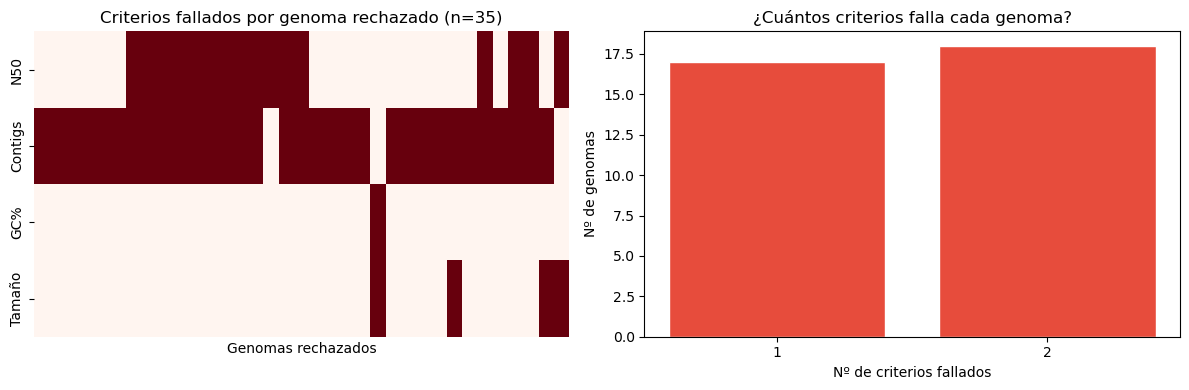

13:21:02 [INFO] Figura guardada → /mnt/c/Users/Alumno1/ablda/amr-resistance-prediction/informes/figuras/02_qc_fallos_heatmap.png


In [8]:
# ── Heatmap de combinaciones de fallo ────────────────────────────────────────
# ¿Cuántos genomas fallan por múltiples criterios simultáneamente?
df_fallan = df_qc[~df_qc["pasa_qc"]][["ok_n50", "ok_contigs", "ok_gc", "ok_size"]]

if not df_fallan.empty:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Heatmap de fallos por criterio (binario)
    fallos_bin = (~df_fallan).astype(int)  # True = falla ese criterio
    fallos_bin.columns = ["N50", "Contigs", "GC%", "Tamaño"]

    sns.heatmap(
        fallos_bin.T,
        ax=axes[0], cmap="Reds", cbar=False,
        xticklabels=False, yticklabels=True,
    )
    axes[0].set_title(f"Criterios fallados por genoma rechazado (n={len(df_fallan)})")
    axes[0].set_xlabel("Genomas rechazados")

    # Barra: nº de criterios fallados por genoma
    n_criterios_fallados = fallos_bin.sum(axis=1).value_counts().sort_index()
    axes[1].bar(n_criterios_fallados.index.astype(str),
                n_criterios_fallados.values,
                color=COLOR_UMBR, edgecolor="white")
    axes[1].set_xlabel("Nº de criterios fallados")
    axes[1].set_ylabel("Nº de genomas")
    axes[1].set_title("¿Cuántos criterios falla cada genoma?")

    plt.tight_layout()
    ruta_fig3 = DIR_FIGS / "02_qc_fallos_heatmap.png"
    plt.savefig(ruta_fig3, dpi=150, bbox_inches="tight")
    plt.show()
    log.info(f"Figura guardada → {ruta_fig3}")
else:
    print("Todos los genomas pasan el QC — no hay rechazados para visualizar.")

---
## Celda 6 — Análisis de sesgo de QC sobre fenotipos

Antes de confirmar los umbrales, comprobamos si los genomas rechazados son
representativos de ambas clases. Si el QC rechazara sistemáticamente más
resistentes que susceptibles (o viceversa), estaría introduciendo sesgo en el
conjunto de entrenamiento.

In [9]:
# Merge de métricas QC con fenotipos
df_qc_fenotipo = df_qc.merge(
    df_fenotipos,
    on="genome_id",
    how="left",
)

# Tabla cruzada: fenotipo × resultado QC
tabla_cruzada = pd.crosstab(
    df_qc_fenotipo["resistant_phenotype"],
    df_qc_fenotipo["pasa_qc"].map({True: "Pasa QC", False: "Rechazado"}),
    margins=True,
)
print("Tabla cruzada: fenotipo × resultado QC")
print(tabla_cruzada)
print()

# Tasa de rechazo por fenotipo
tasa_rechazo = df_qc_fenotipo.groupby("resistant_phenotype")["pasa_qc"].agg(
    total="count",
    pasan="sum",
).assign(
    rechazados=lambda d: d["total"] - d["pasan"],
    tasa_rechazo_pct=lambda d: (d["rechazados"] / d["total"] * 100).round(1),
)
print("Tasa de rechazo por fenotipo:")
print(tasa_rechazo)

# Alerta si la diferencia en tasa de rechazo supera un umbral razonable
if len(tasa_rechazo) == 2:
    diff_rechazo = tasa_rechazo["tasa_rechazo_pct"].max() - tasa_rechazo["tasa_rechazo_pct"].min()
    if diff_rechazo > 10:
        print(f"\n⚠️  Diferencia de tasa de rechazo entre S y R: {diff_rechazo:.1f} pp")
        print("   El QC puede estar introduciendo sesgo. Revisar umbrales.")
    else:
        print(f"\n✓  Diferencia de tasa de rechazo S vs R: {diff_rechazo:.1f} pp — sesgo despreciable")

Tabla cruzada: fenotipo × resultado QC
pasa_qc              Pasa QC  Rechazado  All
resistant_phenotype                         
Resistant                252         12  264
Susceptible              247         19  266
All                      499         31  530

Tasa de rechazo por fenotipo:
                     total  pasan  rechazados  tasa_rechazo_pct
resistant_phenotype                                            
Resistant              264    252          12               4.5
Susceptible            266    247          19               7.1

✓  Diferencia de tasa de rechazo S vs R: 2.6 pp — sesgo despreciable


DISTRIBUCIÓN FINAL POST-QC
resistant_phenotype
Resistant      252
Susceptible    247
Name: count, dtype: int64

Ratio S:R = 0.49 : 0.51
✓  Balance aceptable para clasificación binaria


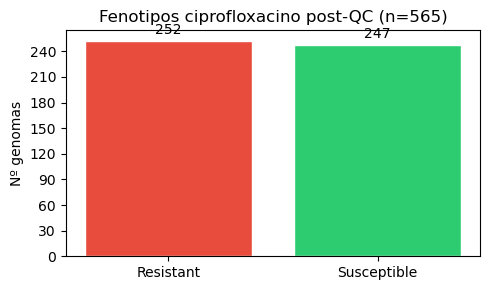

13:21:15 [INFO] Figura guardada → /mnt/c/Users/Alumno1/ablda/amr-resistance-prediction/informes/figuras/02_balance_postqc.png


In [10]:
# Balance final de fenotipos en el conjunto aprobado
df_aprobados = df_qc_fenotipo[df_qc_fenotipo["pasa_qc"]].copy()

print("=" * 45)
print("DISTRIBUCIÓN FINAL POST-QC")
print("=" * 45)
dist = df_aprobados["resistant_phenotype"].value_counts()
print(dist)

ratio = df_aprobados["resistant_phenotype"].value_counts(normalize=True)
print(f"\nRatio S:R = {ratio.get('Susceptible', 0):.2f} : {ratio.get('Resistant', 0):.2f}")

if ratio.max() > 0.70:
    print("⚠️  Desbalance notable → usar class_weight='balanced' / scale_pos_weight en modelado")
else:
    print("✓  Balance aceptable para clasificación binaria")

# Visualización
fig, ax = plt.subplots(figsize=(5, 3))
colores = ["#2ecc71" if k == "Susceptible" else "#e74c3c" for k in dist.index]
bars = ax.bar(dist.index, dist.values, color=colores, edgecolor="white")
ax.bar_label(bars, padding=3)
ax.set_title(f"Fenotipos ciprofloxacino post-QC (n={len(df_aprobados)})")
ax.set_ylabel("Nº genomas")
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
plt.tight_layout()
ruta_fig4 = DIR_FIGS / "02_balance_postqc.png"
plt.savefig(ruta_fig4, dpi=150, bbox_inches="tight")
plt.show()
log.info(f"Figura guardada → {ruta_fig4}")

---
## Celda 7 — Guardado de outputs

Generamos tres artefactos para el siguiente notebook:

| Archivo | Descripción |
|---|---|
| `informe_qc_genomas.csv` | Métricas completas + flags QC por genoma |
| `ids_qc_ok.json` | Lista de genome_ids que pasan el QC |
| `informe_qc.json` | Resumen ejecutivo de la ejecución |

In [11]:
# ── 1. CSV con todas las métricas + flags ─────────────────────────────────────
ruta_qc_csv = DIR_PROC / "informe_qc_genomas.csv"
df_qc.to_csv(ruta_qc_csv, index=False)
log.info(f"Informe QC (CSV) → {ruta_qc_csv}  ({ruta_qc_csv.stat().st_size / 1024:.1f} KB)")

# ── 2. JSON con IDs aprobados ─────────────────────────────────────────────────
ids_qc_ok = df_aprobados["genome_id"].tolist()
ruta_ids_qc = DIR_PROC / "ids_qc_ok.json"
with open(ruta_ids_qc, "w") as f:
    json.dump(ids_qc_ok, f, indent=2)
log.info(f"IDs post-QC (JSON) → {ruta_ids_qc}  ({len(ids_qc_ok)} genomas)")

# ── 3. JSON de resumen ejecutivo ──────────────────────────────────────────────
metricas_mediana = {
    col: round(float(df_aprobados[col].median()), 2)
    for col in ["n50", "n_contigs", "gc_percent", "total_length_mb", "l50"]
    if col in df_aprobados.columns
}

informe = {
    "fecha"               : datetime.now().isoformat(),
    "input_genomas"       : len(ids_objetivo),
    "parseados_ok"        : len(df_qc),
    "errores_fasta"       : len(df_errores),
    "pasan_qc"            : n_pasan,
    "fallan_qc"           : n_fallan,
    "tasa_aprobacion_pct" : round(n_pasan / len(df_qc) * 100, 1) if len(df_qc) > 0 else 0,
    "distribucion_sr"     : df_aprobados["resistant_phenotype"].value_counts().to_dict(),
    "metricas_mediana"    : metricas_mediana,
    "umbrales_aplicados"  : {
        "n50_min_bp"       : QC_MIN_N50_BP,
        "contigs_max"      : QC_MAX_CONTIGS,
        "gc_min_pct"       : QC_MIN_GC,
        "gc_max_pct"       : QC_MAX_GC,
        "size_min_mb"      : QC_MIN_SIZE_MB,
        "size_max_mb"      : QC_MAX_SIZE_MB,
    },
    "archivos_output"     : {
        "csv_metricas" : str(ruta_qc_csv),
        "ids_json"     : str(ruta_ids_qc),
    }
}

ruta_inf = DIR_PROC / "informe_qc.json"
with open(ruta_inf, "w") as f:
    json.dump(informe, f, indent=2, ensure_ascii=False)

print(json.dumps(informe, indent=2, ensure_ascii=False))
log.info(f"Informe resumen → {ruta_inf}")

13:21:19 [INFO] Informe QC (CSV) → /mnt/c/Users/Alumno1/ablda/amr-resistance-prediction/datos/procesados/informe_qc_genomas.csv  (57.3 KB)
13:21:19 [INFO] IDs post-QC (JSON) → /mnt/c/Users/Alumno1/ablda/amr-resistance-prediction/datos/procesados/ids_qc_ok.json  (565 genomas)
13:21:19 [INFO] Informe resumen → /mnt/c/Users/Alumno1/ablda/amr-resistance-prediction/datos/procesados/informe_qc.json


{
  "fecha": "2026-03-18T13:21:19.334539",
  "input_genomas": 600,
  "parseados_ok": 600,
  "errores_fasta": 0,
  "pasan_qc": 565,
  "fallan_qc": 35,
  "tasa_aprobacion_pct": 94.2,
  "distribucion_sr": {
    "Resistant": 252,
    "Susceptible": 247
  },
  "metricas_mediana": {
    "n50": 213453.0,
    "n_contigs": 100.0,
    "gc_percent": 57.21,
    "total_length_mb": 5.54,
    "l50": 9.0
  },
  "umbrales_aplicados": {
    "n50_min_bp": 20000,
    "contigs_max": 500,
    "gc_min_pct": 50.0,
    "gc_max_pct": 64.0,
    "size_min_mb": 4.5,
    "size_max_mb": 6.5
  },
  "archivos_output": {
    "csv_metricas": "/mnt/c/Users/Alumno1/ablda/amr-resistance-prediction/datos/procesados/informe_qc_genomas.csv",
    "ids_json": "/mnt/c/Users/Alumno1/ablda/amr-resistance-prediction/datos/procesados/ids_qc_ok.json"
  }
}


---
## Celda 8 — Análisis de correlación entre métricas

Útil para detectar métricas redundantes antes de decidir qué usar en el siguiente paso.

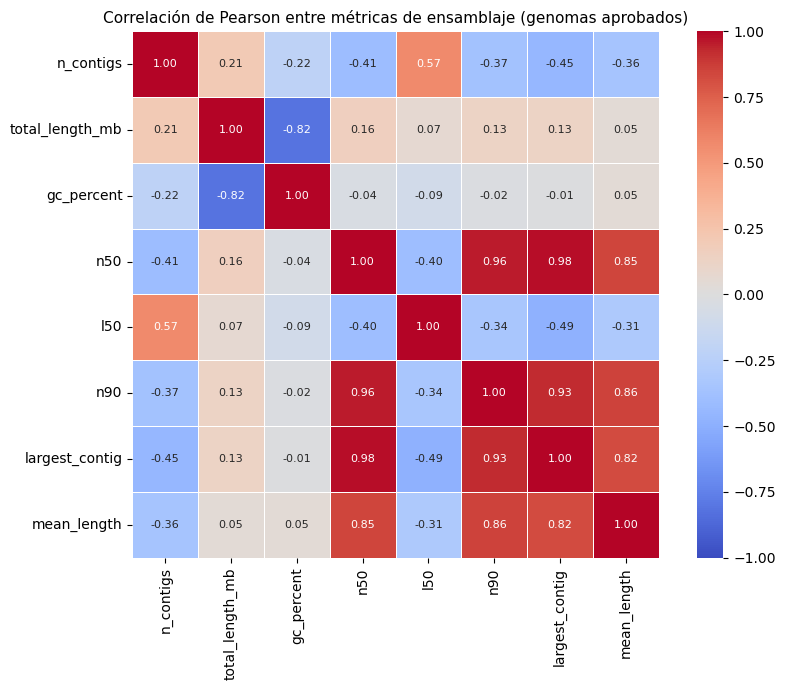

Correlaciones destacadas (|r| > 0.7):
  total_length_mb      — gc_percent           : r = -0.816
  n50                  — n90                  : r = +0.959
  n50                  — largest_contig       : r = +0.977
  n50                  — mean_length          : r = +0.847
  n90                  — largest_contig       : r = +0.929
  n90                  — mean_length          : r = +0.859
  largest_contig       — mean_length          : r = +0.822


In [12]:
cols_corr = ["n_contigs", "total_length_mb", "gc_percent",
             "n50", "l50", "n90", "largest_contig", "mean_length"]

corr_matrix = df_aprobados[cols_corr].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    corr_matrix,
    annot=True, fmt=".2f", cmap="coolwarm",
    center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.5,
    ax=ax, annot_kws={"size": 8},
)
ax.set_title("Correlación de Pearson entre métricas de ensamblaje (genomas aprobados)",
             fontsize=11)
plt.tight_layout()
ruta_fig5 = DIR_FIGS / "02_qc_correlacion_metricas.png"
plt.savefig(ruta_fig5, dpi=150, bbox_inches="tight")
plt.show()

# Observaciones clave
print("Correlaciones destacadas (|r| > 0.7):")
for i in range(len(cols_corr)):
    for j in range(i+1, len(cols_corr)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.70:
            print(f"  {cols_corr[i]:20s} — {cols_corr[j]:20s} : r = {r:+.3f}")

---

## Resumen del notebook

| | Valor |
|---|---|
| Genomas de entrada | `len(ids_objetivo)` |
| Pasan QC | `n_pasan` |
| Fallan QC | `n_fallan` |
| Output principal | `datos/procesados/ids_qc_ok.json` |

**Siguiente paso:** `03_variable_target.ipynb` — procesamiento de etiquetas S/I/R y valores MIC.